In [53]:
#package imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV,  StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, auc




In [54]:
#load dataset
df = pd.read_csv("Diabetes_prediction.csv")

In [55]:
# remove unrealistic values
df = df[(df['Age'] > 0) & (df['Insulin'] > 0)]

In [56]:
#explore dataset
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 871 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               871 non-null    int64  
 1   Glucose                   871 non-null    float64
 2   BloodPressure             871 non-null    float64
 3   SkinThickness             871 non-null    float64
 4   Insulin                   871 non-null    float64
 5   BMI                       871 non-null    float64
 6   DiabetesPedigreeFunction  871 non-null    float64
 7   Age                       871 non-null    float64
 8   Diagnosis                 871 non-null    int64  
dtypes: float64(7), int64(2)
memory usage: 68.0 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
count,871.000000,871.000000,871.000000,871.000000,871.000000,871.000000,871.000000,871.000000,871.000000
mean,1.779564,99.697937,72.008000,23.286730,102.497880,25.458797,0.450980,43.405284,0.306544
std,1.344070,19.435765,13.899782,1.187817,61.229475,3.704433,0.197519,14.337710,0.461323
min,0.000000,30.571402,31.401487,19.369987,0.101435,13.548818,0.100037,2.082077,0.000000
25%,1.000000,86.437862,62.788266,22.505360,56.282346,23.044715,0.285970,33.672354,0.000000
50%,2.000000,99.669285,71.583617,23.282376,97.810429,25.455090,0.448008,43.650701,0.000000
75%,3.000000,113.106420,81.283215,24.060591,140.314690,28.056858,0.617229,53.188521,1.000000
max,6.000000,161.238939,110.723715,26.917654,317.701852,35.402615,0.799654,90.573782,1.000000


In [57]:
#check for missing values in respective columns
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols] = df[cols].replace(0, np.nan)



In [58]:
df.isnull().sum()
#look to see how many missing values there are

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Diagnosis                   0
dtype: int64

In [59]:
df['Diagnosis'].value_counts()
#diagnosis is the target variable

Diagnosis
0    604
1    267
Name: count, dtype: int64

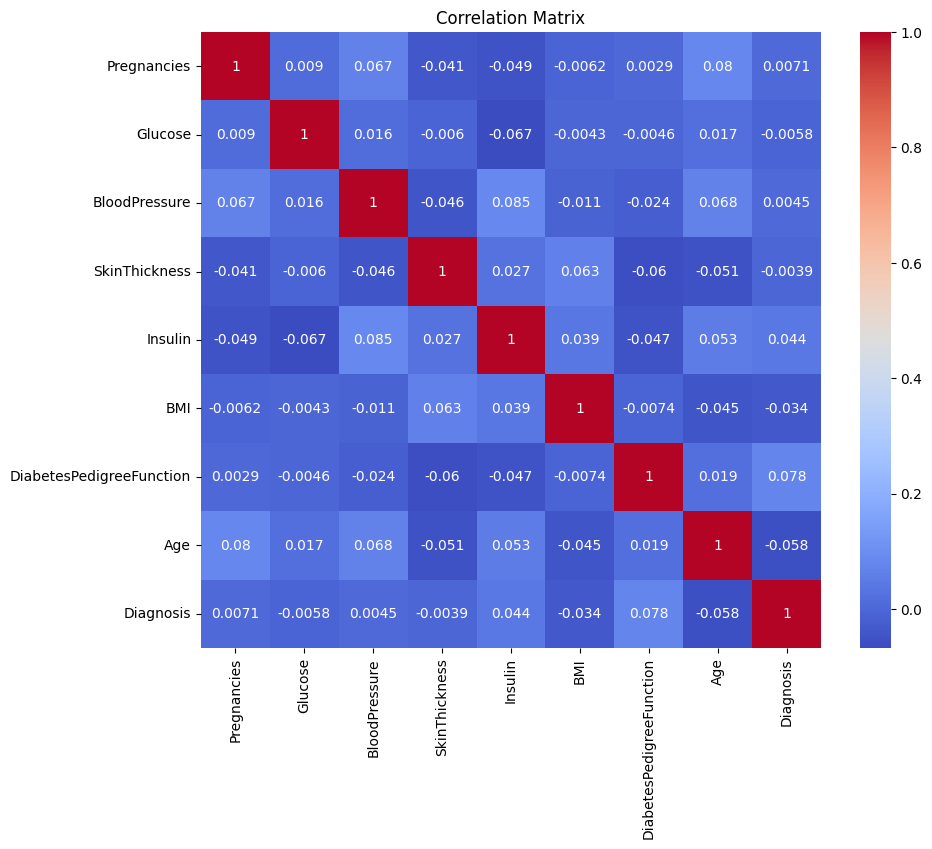

In [60]:
#correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [61]:
#feature engineering
df['Glucose_BMI'] = df['Glucose'] * df['BMI']

In [62]:
#split data
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [64]:
#scale data
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [65]:
#set up cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [66]:
#logistic regression
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)

log_scores = cross_val_score(
    log_model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print("Logistic Regression ROC-AUC:", log_scores.mean())

Logistic Regression ROC-AUC: 0.5329836256008038


In [67]:
#decision tree
tree_model = DecisionTreeClassifier(max_depth=5)

tree_scores = cross_val_score(
    tree_model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print("Decision Tree ROC-AUC:", tree_scores.mean())

Decision Tree ROC-AUC: 0.5279740141681223


In [68]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

rf_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print("Random Forest ROC-AUC:", rf_scores.mean())

Random Forest ROC-AUC: 0.5088911817424165


In [69]:
#train logistic regression
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [70]:
#evaluate
y_probs = log_model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, y_probs)

0.5267829813284359

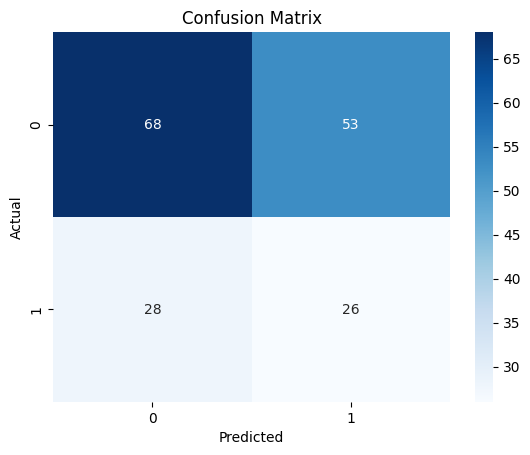

In [71]:
#confusion matrix
y_pred = log_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [72]:
#feature importance
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
6,DiabetesPedigreeFunction,0.310016
4,Insulin,0.209482
1,Glucose,0.127620
0,Pregnancies,0.067464
5,BMI,0.013262
2,BloodPressure,0.012461
3,SkinThickness,0.011427
8,Glucose_BMI,-0.098110
7,Age,-0.255431


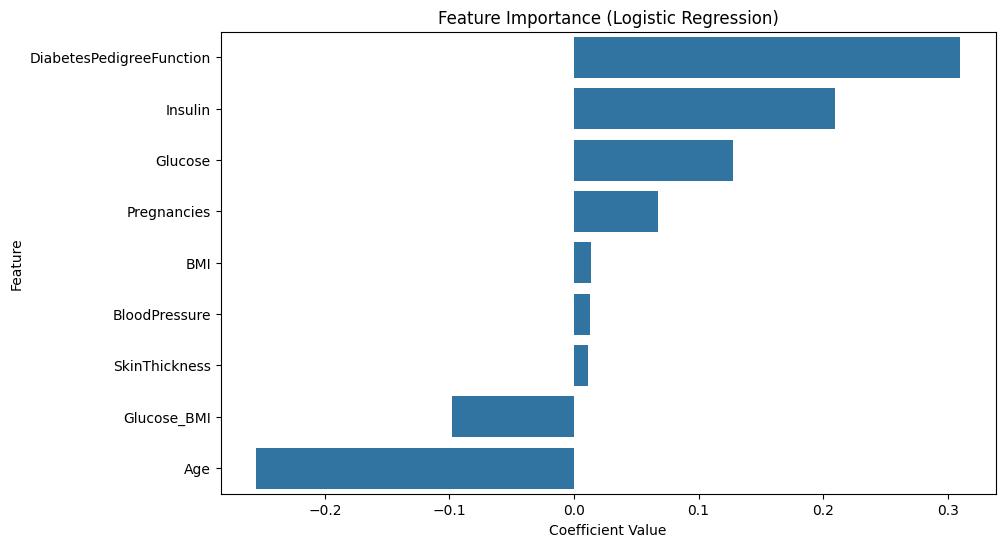

In [73]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

# Sort values
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.show()

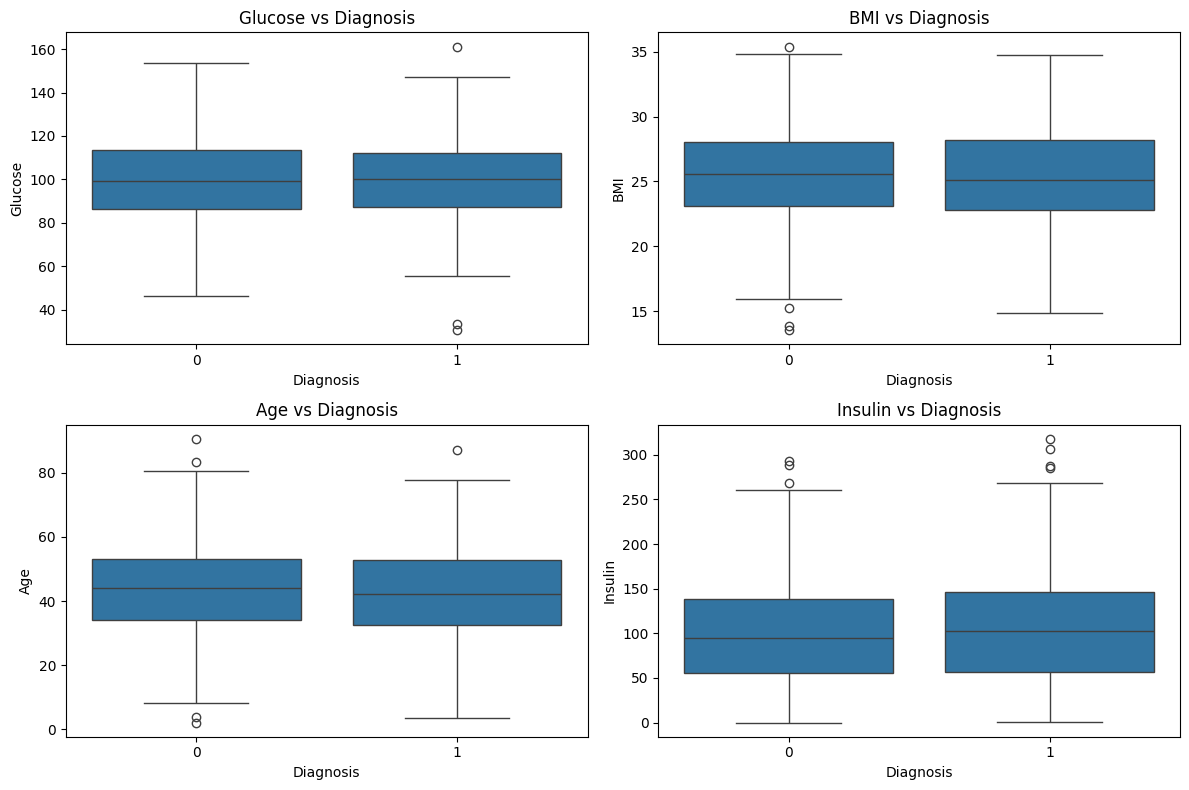

In [74]:
plt.figure(figsize=(12,8))

features = ['Glucose', 'BMI', 'Age', 'Insulin']

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Diagnosis', y=col, data=df)
    plt.title(f"{col} vs Diagnosis")

plt.tight_layout()
plt.show()

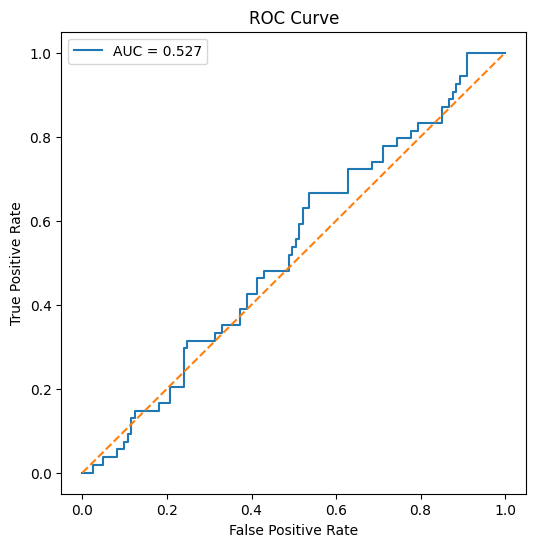

In [75]:
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_probs):.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()